In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
import joblib

from sklearn.linear_model import LogisticRegression


# 1. Load Data
data = np.load('../data/fashion_data_complete.npz')

X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']

# Use only 10,000 training samples for tuning
X_train_small = X_train[:10000]
y_train_small = y_train[:10000]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 2. Hyperparameter Tuning
n_estimators_list = [50, 100, 200]
max_depth_list = [10, 20, None]

results = {
    'depth_10': [],
    'depth_20': [],
    'depth_None': []
}

print("Starting Random Forest Hyperparameter Tuning...")

for max_depth in max_depth_list:
    key = f"depth_{max_depth}"
    print(f"\n--- Testing max_depth = {max_depth} ---")
    
    for n_estimators in n_estimators_list:
        start = time.time()

        rf_model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42,
            n_jobs=-1
        )

        rf_model.fit(X_train_small, y_train_small)
        val_acc = rf_model.score(X_val, y_val)
        results[key].append(val_acc)

        end = time.time()
        print(f"n_estimators={n_estimators:3d} | Val Acc: {val_acc:.4f} | Time: {end-start:.2f}s")


# 3. Visualization for Report
plt.figure(figsize=(10, 6))

plt.plot(n_estimators_list, results['depth_10'], marker='o', label='max_depth=10')
plt.plot(n_estimators_list, results['depth_20'], marker='s', label='max_depth=20')
plt.plot(n_estimators_list, results['depth_None'], marker='^', label='max_depth=None')

plt.title('Random Forest Tuning: Number of Trees vs Max Depth')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Validation Accuracy')
plt.xticks(n_estimators_list)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# 4. Find Best Parameters
best_acc = -1
best_n_estimators = None
best_max_depth = None

for max_depth in max_depth_list:
    key = f"depth_{max_depth}"
    for i, n_estimators in enumerate(n_estimators_list):
        acc = results[key][i]
        if acc > best_acc:
            best_acc = acc
            best_n_estimators = n_estimators
            best_max_depth = max_depth

print(f"\nBest parameters found:")
print(f"n_estimators = {best_n_estimators}")
print(f"max_depth    = {best_max_depth}")
print(f"Best Val Acc = {best_acc:.4f}")

# 5. Train Final Model on Full Training Set
print("\nTraining final Random Forest model on full training set...")

final_rf = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train, y_train)

# Save model
joblib.dump(final_rf, 'random_forest_fashion_model.joblib')
print("Saved: random_forest_fashion_model.joblib")

Starting MLP Hyperparameter Tuning...
Hidden=(256,) | alpha=1e-05 | lr=0.0005 | Val Acc: 0.8630 | Time: 15.96s
Hidden=(256,) | alpha=1e-05 | lr=0.001 | Val Acc: 0.8610 | Time: 14.40s
Hidden=(256,) | alpha=0.0001 | lr=0.0005 | Val Acc: 0.8526 | Time: 7.91s
Hidden=(256,) | alpha=0.0001 | lr=0.001 | Val Acc: 0.8601 | Time: 19.94s
Hidden=(128, 64) | alpha=1e-05 | lr=0.0005 | Val Acc: 0.8501 | Time: 4.88s
Hidden=(128, 64) | alpha=1e-05 | lr=0.001 | Val Acc: 0.8600 | Time: 6.39s
Hidden=(128, 64) | alpha=0.0001 | lr=0.0005 | Val Acc: 0.8535 | Time: 8.08s
Hidden=(128, 64) | alpha=0.0001 | lr=0.001 | Val Acc: 0.8605 | Time: 8.21s
Hidden=(256, 128) | alpha=1e-05 | lr=0.0005 | Val Acc: 0.8629 | Time: 18.03s
Hidden=(256, 128) | alpha=1e-05 | lr=0.001 | Val Acc: 0.8633 | Time: 21.87s
Hidden=(256, 128) | alpha=0.0001 | lr=0.0005 | Val Acc: 0.8638 | Time: 15.80s
Hidden=(256, 128) | alpha=0.0001 | lr=0.001 | Val Acc: 0.8641 | Time: 16.44s
Hidden=(128, 128) | alpha=1e-05 | lr=0.0005 | Val Acc: 0.8566 |

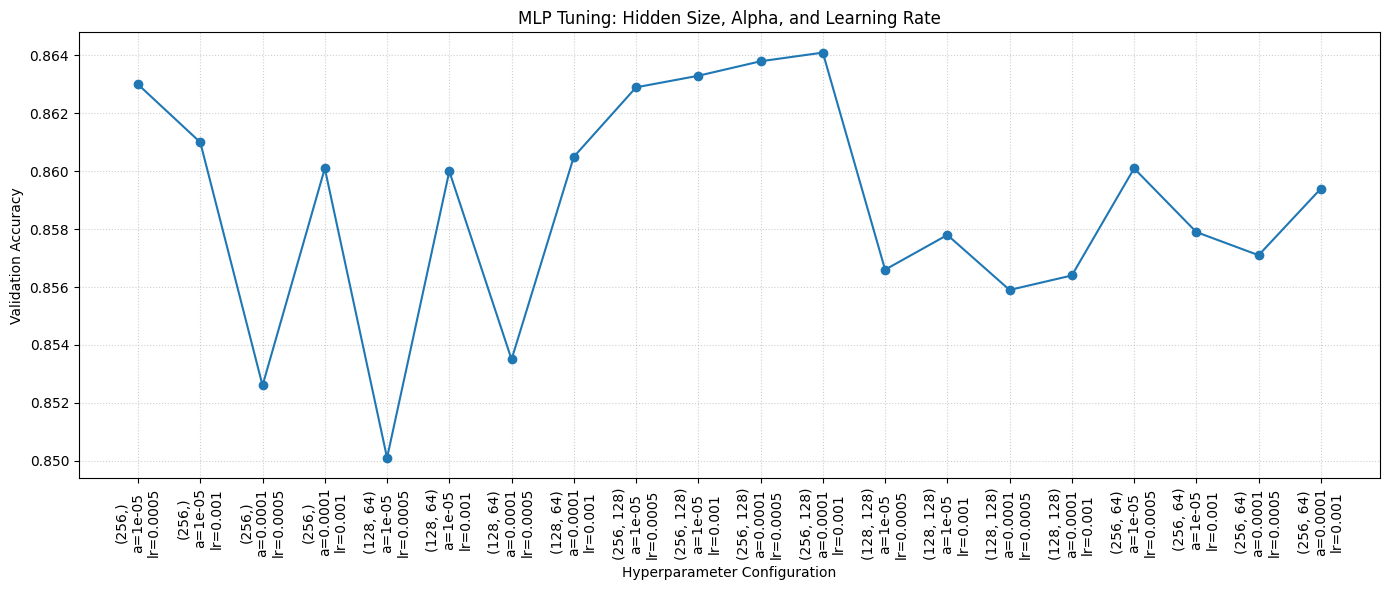

Training final MLP model on full training set...
Saved: mlp_fashion_model.joblib


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import joblib
from sklearn.neural_network import MLPClassifier

# 1. Hyperparameter candidates
hidden_sizes = [
    (256,),
    (128, 64),
    (256, 128),
    (128, 128),
    (256, 64),
]

alpha_values = [1e-5, 1e-4]
learning_rate_values = [0.0005, 0.001]

results = []
all_configs = []

print("Starting MLP Hyperparameter Tuning...")

# 2. Grid Search over hidden size, alpha, learning_rate_init
for hidden in hidden_sizes:
    for alpha in alpha_values:
        for lr in learning_rate_values:
            start = time.time()

            mlp_model = MLPClassifier(
                hidden_layer_sizes=hidden,
                activation='relu',
                solver='adam',
                alpha=alpha,
                batch_size=128,
                learning_rate_init=lr,
                max_iter=30,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=5,
                random_state=42
            )

            mlp_model.fit(X_train_small, y_train_small)
            val_acc = mlp_model.score(X_val, y_val)

            results.append(val_acc)
            all_configs.append((hidden, alpha, lr))

            end = time.time()
            print(
                f"Hidden={hidden} | alpha={alpha} | lr={lr} "
                f"| Val Acc: {val_acc:.4f} | Time: {end-start:.2f}s"
            )

# 3. Find best configuration
best_idx = np.argmax(results)
best_hidden, best_alpha, best_lr = all_configs[best_idx]

print("\nBest configuration found:")
print(f"hidden_layer_sizes = {best_hidden}")
print(f"alpha              = {best_alpha}")
print(f"learning_rate_init = {best_lr}")
print(f"best_val_acc       = {results[best_idx]:.4f}")

# 4. Visualization for Report
labels = [
    f"{hidden}\na={alpha}\nlr={lr}"
    for hidden, alpha, lr in all_configs
]

plt.figure(figsize=(14, 6))
plt.plot(range(len(results)), results, marker='o')
plt.xticks(range(len(labels)), labels, rotation=90)
plt.title('MLP Tuning: Hidden Size, Alpha, and Learning Rate')
plt.xlabel('Hyperparameter Configuration')
plt.ylabel('Validation Accuracy')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 5. Train Final Model on Full Training Set
final_mlp = MLPClassifier(
    hidden_layer_sizes=best_hidden,
    activation='relu',
    solver='adam',
    alpha=best_alpha,
    batch_size=128,
    learning_rate_init=best_lr,
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=42
)

print("Training final MLP model on full training set...")
final_mlp.fit(X_train, y_train)

# Save model
joblib.dump(final_mlp, 'mlp_fashion_model.joblib')
print("Saved: mlp_fashion_model.joblib")